# Google DeepMind compute model

A Monte Carlo estimate of Google DeepMind's compute, in H100-equivalents (H100e).

DeepMind compute is built up as a product of five pieces:

1. **Total Google owned H100e** — Nvidia fleet + Google TPU fleet, sampled
   independently from the lognormal CIs in the dashboard.
2. **Deployment lag** (operational / owned) — only part of the owned fleet is
   actually online at any moment.
3. **Cloud share of Google ML compute** — the CFO's "around half" split between
   external cloud customers and Google-internal workloads.
4. **DeepMind's share of the cloud half** — enterprise Gemini inference
   (Vertex + Gemini Enterprise) as a fraction of cloud-side compute.
5. **DeepMind's share of the non-cloud half** — consumer Gemini inference plus
   DM research/training, as a fraction of internal compute (the rest being
   recommenders, Waymo, etc.).

The DeepMind fraction of operational compute is

> `cloud_share · dm_cloud_share + (1 − cloud_share) · dm_noncloud_share`

**All inputs are lognormal.** Each parameter's low/high bounds are read as the
**90% credible interval** (5th–95th percentile), so the lognormal median lands
near the geometric mean of the two bounds.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import squigglepy as sq
from squigglepy.numbers import K, M

N_SAMPLES = 5000
np.random.seed(42)


def fmt(x):
    """Format an H100e count for labels (millions or thousands)."""
    if x >= 1e6:
        return f"{x / 1e6:.2f}M"
    return f"{x / 1e3:.0f}k"


def summary(name, samples):
    """Print 5th / median / 95th and mean for a sample array.

    Values below 10 are treated as fractions and shown as decimals; larger
    values are H100e counts and shown in millions/thousands.
    """
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    f = (lambda x: f"{x:.3f}") if np.median(samples) < 10 else fmt
    print(f"{name}")
    print(f"  90% CI : {f(p[5])} – {f(p[95])}")
    print(f"  median : {f(p[50])}")
    print(f"  mean   : {f(np.mean(samples))}")
    return p


## 1. Total Google owned H100e

Lognormal fits to the dashboard 90% CIs. The Nvidia and TPU fleets are drawn
independently, so an unlucky Nvidia quarter need not coincide with an unlucky
TPU quarter. (There's a concern the reported TPU CI is too tight; rather than
bake that into the base case, we test it in the sensitivity check at the end.)

In [2]:
nvidia_owned = sq.to(955 * K, 1.59 * M)   # median ~1.24M
google_owned = sq.to(3.08 * M, 4.54 * M)  # median ~3.74M

nvidia_samples = nvidia_owned @ N_SAMPLES
google_samples = google_owned @ N_SAMPLES
total_owned = nvidia_samples + google_samples

summary("Nvidia owned", nvidia_samples)
summary("Google (TPU) owned", google_samples)
summary("Total Google owned H100e", total_owned);

Nvidia owned
  90% CI : 956k – 1.58M
  median : 1.24M
  mean   : 1.25M
Google (TPU) owned
  90% CI : 3.07M – 4.54M
  median : 3.73M
  mean   : 3.76M
Total Google owned H100e
  90% CI : 4.25M – 5.83M
  median : 4.98M
  mean   : 5.01M


## 2. Deployment lag (operational / owned)

Extrapolating the lag→ratio mapping (each extra quarter of lag shaves ~1.1M off
the operational fleet): a 0.5-quarter lag implies ~0.87, a 1-quarter lag ~0.76,
a 2-quarter lag ~0.55. We take the 90% CI as the **0.5- to 2-quarter** range,
i.e. 0.55–0.87. The lognormal median lands around 0.69, which puts the
1-quarter scenario (0.76) close to the median rather than out at the tail.

In [3]:
deployment_lag = sq.to(0.55, 0.87)
deployment_lag_samples = deployment_lag @ N_SAMPLES
operational = total_owned * deployment_lag_samples

summary("Deployment lag", deployment_lag_samples)
summary("Operational H100e", operational);

Deployment lag
  90% CI : 0.550 – 0.869
  median : 0.689
  mean   : 0.697
Operational H100e
  90% CI : 2.62M – 4.55M
  median : 3.43M
  mean   : 3.49M


## 3. Cloud share of Google ML compute

CFO: "around half" in 2025, "just over half" for 2026. Lognormal over a tight
0.45–0.55 band, median ~0.50.

In [4]:
cloud_share = sq.to(0.45, 0.55)
cloud_share_samples = cloud_share @ N_SAMPLES
summary("Cloud share of Google ML compute", cloud_share_samples);

Cloud share of Google ML compute
  90% CI : 0.451 – 0.552
  median : 0.498
  mean   : 0.499


## 4 & 5. DeepMind's share of each half

- **Cloud half:** enterprise Gemini inference is "probably under 1M H100e"
  against a cloud half of ~1.6–2M, so the share is well under 0.5. Lognormal
  over 0.25–0.55 (left bound raised from 0.15 — a share that low looked
  implausible), median ~0.37.
- **Non-cloud half:** splits between DeepMind-related work (consumer Gemini
  inference, DM R&D/training) and other internal workloads (recommenders ~1M,
  Waymo, etc.). DeepMind can plausibly be *more than half* of internal compute
  even though it's less than half of Google's total — the earlier "non-DeepMind
  internal is larger" note was a comparison against DeepMind's *cloud-side*
  compute, not a ceiling on this share. Lognormal over 0.33–0.75, median ~0.50.

In [5]:
dm_cloud_share = sq.to(0.25, 0.55)
dm_noncloud_share = sq.to(0.33, 0.75)

dm_cloud_share_samples = dm_cloud_share @ N_SAMPLES
dm_noncloud_share_samples = dm_noncloud_share @ N_SAMPLES

summary("DM share of cloud half", dm_cloud_share_samples)
summary("DM share of non-cloud half", dm_noncloud_share_samples);

DM share of cloud half
  90% CI : 0.250 – 0.556
  median : 0.372
  mean   : 0.383
DM share of non-cloud half
  90% CI : 0.334 – 0.747
  median : 0.501
  mean   : 0.515


## Combine: DeepMind compute

DeepMind's fraction of operational compute is the cloud-weighted blend of its
two sub-shares; multiply by operational H100e to get DeepMind compute.

In [6]:
dm_fraction = (
    cloud_share_samples * dm_cloud_share_samples
    + (1 - cloud_share_samples) * dm_noncloud_share_samples
)
dm_compute = operational * dm_fraction

p = sq.get_percentiles(dm_fraction, percentiles=[5, 50, 95])
print(f"DeepMind fraction of OPERATIONAL compute")
print(f"  90% CI : {p[5]:.3f} – {p[95]:.3f}")
print(f"  median : {p[50]:.3f}\n")

summary("DeepMind H100e", dm_compute);

DeepMind fraction of OPERATIONAL compute
  90% CI : 0.330 – 0.591
  median : 0.443

DeepMind H100e
  90% CI : 1.02M – 2.29M
  median : 1.52M
  mean   : 1.57M


## Intermediate: DeepMind's overall share of operational Google compute

DeepMind compute as a fraction of the *operational* fleet. This equals the
cloud-weighted blend of the two sub-shares from the previous step.

DeepMind share of OPERATIONAL Google compute
  90% CI : 0.330 – 0.591   median: 0.443


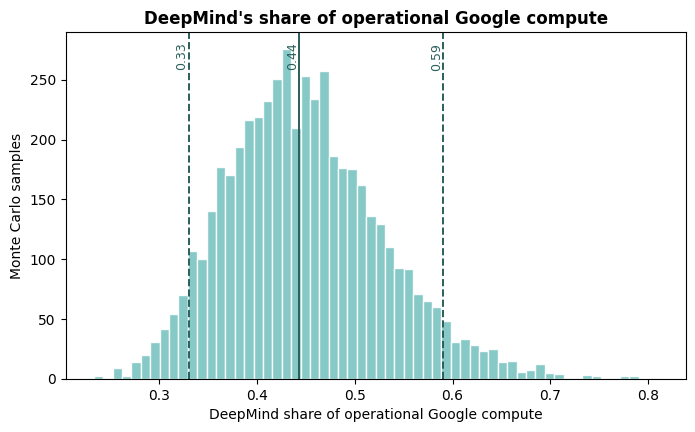

In [7]:
share_of_operational = dm_compute / operational

pp = sq.get_percentiles(share_of_operational, percentiles=[5, 50, 95])
print("DeepMind share of OPERATIONAL Google compute")
print(f"  90% CI : {pp[5]:.3f} – {pp[95]:.3f}   median: {pp[50]:.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(share_of_operational, bins=60, color="#7AC4C0", alpha=0.9,
        edgecolor="white")
for q, style in [(5, "--"), (50, "-"), (95, "--")]:
    ax.axvline(pp[q], color="#2B5F5C", ls=style, lw=1.4)
    ax.text(pp[q], ax.get_ylim()[1] * 0.97, f"{pp[q]:.2f}", rotation=90,
            va="top", ha="right", fontsize=9, color="#2B5F5C")
ax.set_xlabel("DeepMind share of operational Google compute")
ax.set_ylabel("Monte Carlo samples")
ax.set_title("DeepMind's share of operational Google compute", weight="bold")
plt.show()

## Monte Carlo summary

The DeepMind total is exactly the product of three sampled parameters:

> `DeepMind H100e = total_owned × deployment_lag × DeepMind_fraction`

Each box plot below shows one of those parameters (box = interquartile range,
line = median, whiskers = 90% CI). The first three multiply together into the
DeepMind total on the right. Because the inputs sit on very different scales
(millions vs. fractions), each panel keeps its own y-axis.

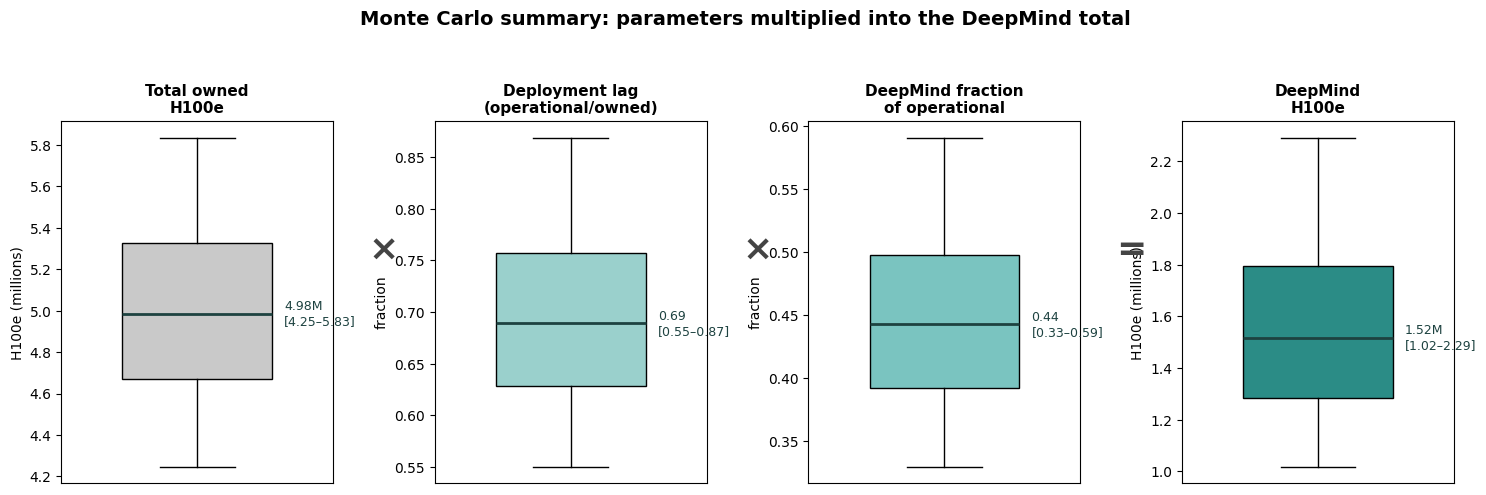

In [8]:
panels = [
    ("Total owned\nH100e", total_owned / 1e6, "#C9C9C9", "M"),
    ("Deployment lag\n(operational/owned)", deployment_lag_samples, "#9AD0CC", "f"),
    ("DeepMind fraction\nof operational", dm_fraction, "#7AC4C0", "f"),
    ("DeepMind\nH100e", dm_compute / 1e6, "#2B8C86", "M"),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, (label, data, color, kind) in zip(axes, panels):
    bp = ax.boxplot(data, whis=[5, 95], showfliers=False, widths=0.55,
                    patch_artist=True,
                    medianprops=dict(color="#1d4240", lw=2))
    bp["boxes"][0].set_facecolor(color)
    ax.set_xticks([])
    ax.set_title(label, fontsize=11, weight="bold")
    med = np.median(data)
    lo, hi = np.percentile(data, [5, 95])
    unit = "M" if kind == "M" else ""
    ax.text(1.32, med, f"{med:.2f}{unit}\n[{lo:.2f}–{hi:.2f}]",
            va="center", ha="left", fontsize=9, color="#1d4240")
    ax.set_ylabel("H100e (millions)" if kind == "M" else "fraction")
    ax.margins(x=0.4)

fig.suptitle("Monte Carlo summary: parameters multiplied into the DeepMind total",
             fontsize=14, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])

# Draw the x / x / = operators in the gaps between panels.
fig.canvas.draw()
for i, sym in enumerate(["\u00d7", "\u00d7", "="]):
    b0, b1 = axes[i].get_position(), axes[i + 1].get_position()
    fig.text((b0.x1 + b1.x0) / 2, 0.5, sym, fontsize=26, weight="bold",
             ha="center", va="center", color="#444")
plt.show()

## Final visualization

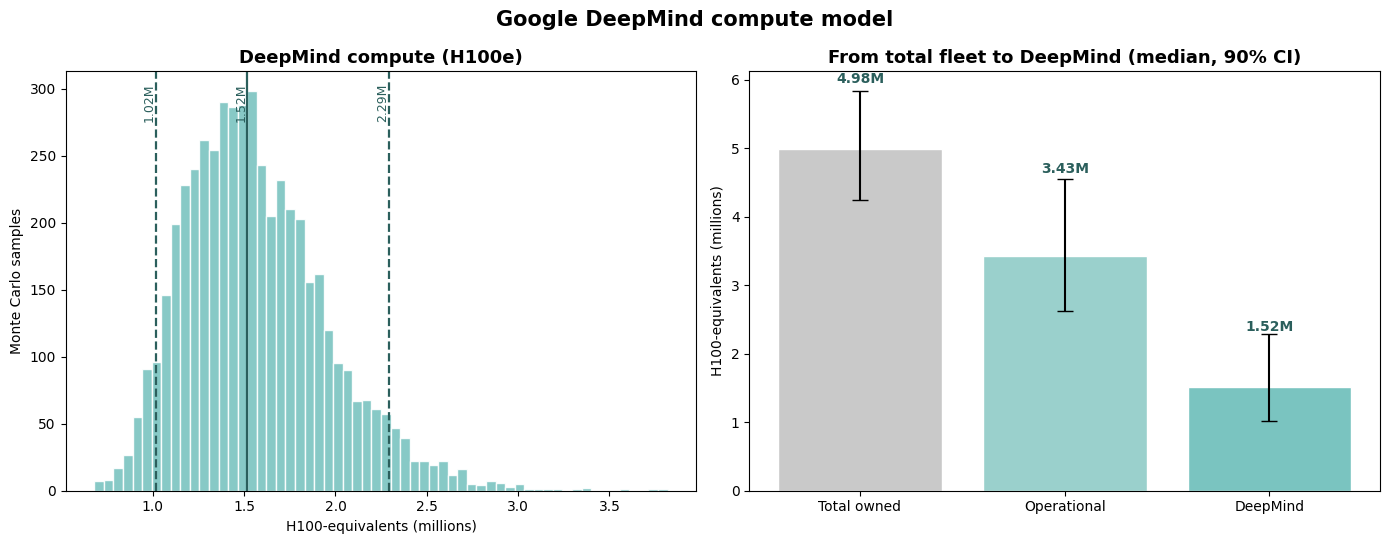

In [9]:
dm_pct = sq.get_percentiles(dm_compute, percentiles=[5, 50, 95])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Distribution of DeepMind compute
ax = axes[0]
ax.hist(dm_compute / 1e6, bins=60, color="#7AC4C0", edgecolor="white", alpha=0.9)
for q, style in [(5, "--"), (50, "-"), (95, "--")]:
    v = dm_pct[q] / 1e6
    ax.axvline(v, color="#2B5F5C", linestyle=style, linewidth=1.6)
    ax.text(v, ax.get_ylim()[1] * 0.97, fmt(dm_pct[q]), rotation=90,
            va="top", ha="right", fontsize=9, color="#2B5F5C")
ax.set_title("DeepMind compute (H100e)", fontsize=13, weight="bold")
ax.set_xlabel("H100-equivalents (millions)")
ax.set_ylabel("Monte Carlo samples")

# Waterfall: total owned -> operational -> DeepMind
ax = axes[1]
stages = [("Total owned", total_owned), ("Operational", operational),
          ("DeepMind", dm_compute)]
pos = range(len(stages))
med = [np.median(s) / 1e6 for _, s in stages]
lo = [np.percentile(s, 5) / 1e6 for _, s in stages]
hi = [np.percentile(s, 95) / 1e6 for _, s in stages]
yerr = [np.array(med) - np.array(lo), np.array(hi) - np.array(med)]
ax.bar(pos, med, yerr=yerr, color=["#C9C9C9", "#9AD0CC", "#7AC4C0"],
       capsize=6, edgecolor="white")
for i in pos:
    ax.text(i, hi[i] * 1.02, fmt(med[i] * 1e6), ha="center", fontsize=10,
            color="#2B5F5C", weight="bold")
ax.set_xticks(list(pos))
ax.set_xticklabels([s[0] for s in stages])
ax.set_ylabel("H100-equivalents (millions)")
ax.set_title("From total fleet to DeepMind (median, 90% CI)",
             fontsize=13, weight="bold")

fig.suptitle("Google DeepMind compute model", fontsize=15, weight="bold")
fig.tight_layout()
plt.show()

## Sensitivity check: doubling TPU uncertainty

There's a worry the dashboard's reported TPU CI (3.08M–4.54M) is too tight. Here
we stretch it to **2× its original log-width**, holding the geometric median
(~3.74M) fixed — dashboard 3.08M–4.54M → **2.54M–5.51M** — and propagate it
through the model. We reuse the *same* deployment-lag and DeepMind-fraction draws
as the base case, so the only thing that changes is the TPU spread; this isolates
its downstream effect on the DeepMind total.

Takeaway: because the DeepMind total is a product of several independent uncertain
factors (lag and the DM-fraction carry a lot of the variance), even a 2× widening
of the TPU input passes through only weakly — the DeepMind 90% CI widens modestly
and its median barely moves.

DeepMind H100e — baseline TPU CI (3.08M–4.54M)
  90% CI : 1.02M – 2.29M   median: 1.52M   width: 1.27M
DeepMind H100e — TPU CI doubled (2.54M–5.51M)
  90% CI : 950k – 2.47M   median: 1.53M   width: 1.52M

90% CI width grows +19% (1.27M → 1.52M); median essentially unchanged.


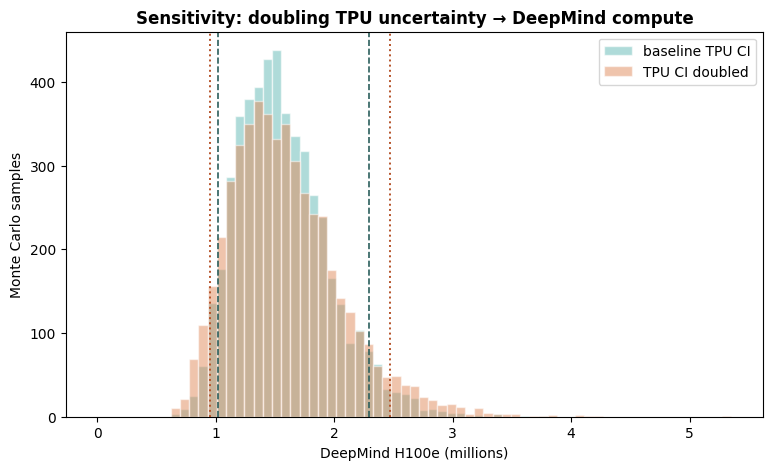

In [10]:
# Widen the TPU CI to 2x its log-width, median (~3.74M) held fixed.
google_owned_wide = sq.to(2.54 * M, 5.51 * M) @ N_SAMPLES

# Reuse the same lag and DM-fraction draws so the ONLY change is TPU spread.
total_owned_wide = nvidia_samples + google_owned_wide
operational_wide = total_owned_wide * deployment_lag_samples
dm_compute_wide = operational_wide * dm_fraction

base = sq.get_percentiles(dm_compute, percentiles=[5, 50, 95])
wide = sq.get_percentiles(dm_compute_wide, percentiles=[5, 50, 95])
base_w, wide_w = base[95] - base[5], wide[95] - wide[5]

print("DeepMind H100e — baseline TPU CI (3.08M–4.54M)")
print(f"  90% CI : {fmt(base[5])} – {fmt(base[95])}   median: {fmt(base[50])}   width: {fmt(base_w)}")
print("DeepMind H100e — TPU CI doubled (2.54M–5.51M)")
print(f"  90% CI : {fmt(wide[5])} – {fmt(wide[95])}   median: {fmt(wide[50])}   width: {fmt(wide_w)}")
print(f"\n90% CI width grows {wide_w / base_w - 1:+.0%} "
      f"({fmt(base_w)} → {fmt(wide_w)}); median essentially unchanged.")

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, max(dm_compute.max(), dm_compute_wide.max()) / 1e6, 70)
ax.hist(dm_compute / 1e6, bins=bins, color="#7AC4C0", alpha=0.6,
        label="baseline TPU CI", edgecolor="white")
ax.hist(dm_compute_wide / 1e6, bins=bins, color="#E08A5B", alpha=0.5,
        label="TPU CI doubled", edgecolor="white")
for v in (base[5], base[95]):
    ax.axvline(v / 1e6, color="#2B5F5C", ls="--", lw=1.2)
for v in (wide[5], wide[95]):
    ax.axvline(v / 1e6, color="#B5532A", ls=":", lw=1.4)
ax.set_xlabel("DeepMind H100e (millions)")
ax.set_ylabel("Monte Carlo samples")
ax.set_title("Sensitivity: doubling TPU uncertainty → DeepMind compute",
             weight="bold")
ax.legend()
plt.show()